# **Esame del 21 gennaio 2025**

- Non si possono consultare libri, note, ed ogni altro materiale o persone durante
l’esame ad eccezione delle funzioni Python fornite.

- Risolvere i seguenti esercizi con l’ausilio di Python.

- La durata del compito è di 90 minuti.

- Questo esame ha 3 domande, per un totale di 30/30 punti.

- Svolgere gli esercizi marcati con **[T]** su fogli protocollo, indicando: nome, cognome, codice persona
e data

# **Esercizio 1 (punti 10)**

Si consideri la seguente matrice:

\begin{gather*}
      A =
  \begin{bmatrix}
1 & \dfrac{1}{2} & \dfrac{1}{3} & \dots & \dfrac{1}{n} \\
\dfrac{1}{2} & \dfrac{1}{3} & \dfrac{1}{4} & \dots & \dfrac{1}{n+1} \\
\dfrac{1}{3} & \dfrac{1}{4} & \dfrac{1}{5} & \dots & \dfrac{1}{n+2} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
\dfrac{1}{n} & \dfrac{1}{n+1} & \dfrac{1}{n+2} & \dots & \dfrac{1}{2n-1}
\end{bmatrix}
\end{gather*}

che può essere generata con il comando $\verb|hilbert|$ di $\verb|scipy.linalg|$.

#### **(1a) (3 punti) [P+T]**  
Enunciare la condizione necessaria e sufficiente per l'esistenza della fattorizzazione LU di una matrice (senza pivoting). Scegliere come dimensione della matrice $n=4$ e verificare con  opportuni comandi se la matrice data soddisfa tale condizione.

In [1]:
# importazione pacchetti
import scipy.linalg
import numpy as np
from functions import fwsub, bksub
import matplotlib.pyplot as plt

##### **Soluzione.** 

 Data una matrice $A\in\mathbb{R}^{n\times n}$ non singolare la fattorizzazione LU senza pivoting esiste ed è unica *se e solo se* tutte le sotto-matrici principali $A_i$ di ordine $i=1\ldots n-1$ sono non singolari 
Costruiamo la matrice:

In [2]:
# dimensione matrice
n = 4

# costruzione matrice A
A = scipy.linalg.hilbert(n)

print(A)

[[1.         0.5        0.33333333 0.25      ]
 [0.5        0.33333333 0.25       0.2       ]
 [0.33333333 0.25       0.2        0.16666667]
 [0.25       0.2        0.16666667 0.14285714]]


Verifichiamo la condizione necessaria e sufficiente:

In [3]:
condition = True
if scipy.linalg.det(A) != 0:
    for i in range(1, n):
        if np.abs(scipy.linalg.det(A[1:i, 1:i])) < 1.0e-16:
            condition = False
else:
    print("matrice singolare")
    condition = False
if condition:
    print("la fattorizzazione è possibile senza pivoting")
else:
    print("NON è possibile la fattorizzazione senza pivoting")

la fattorizzazione è possibile senza pivoting


#### **(1b) (3 punti) [P]**  
Data la soluzione esatta $\mathbf{x}=[1,\,1\,\ldots,1]^\top$ costruire il termine noto $\mathbf{b}$ e risolvere il sistema lineare $A\mathbf{x}=\mathbf{b}$ utilizzando i) la fattorizzazione LU  da scipy.linalg  ii) i metodi di sostituzione in avanti e all'indietro implementati nelle funzioni fornite. Verificare se è stato effettuato il pivoting.

##### **Soluzione.**

Consideriamo il seguente codice.

In [4]:
P, L, U = scipy.linalg.lu(A)

if np.all(P == np.eye(n)):
    print("P = I, no pivoting")
else:
    print("P != I, pivoting")

x_ex = np.ones(n)
b = A @ x_ex

y = fwsub(L, P.T @ b)
x = bksub(U, y)
print(x)

P != I, pivoting
[1. 1. 1. 1.]


Osserviamo che è stato effettuato il pivoting. La soluzione numerica, in questo caso, è praticamente identica alla soluzione esatta.

#### **(1c) (4 punti) [P+T]**  
Ripetere la costruzione del termine noto e la soluzione del sistema per $n=5$, $10$,    $15$. Per ognuno dei casi calcolare la norma dell'errore *relativo* e il condizionamento della matrice e rappresentarli su due grafici in scala logaritmica. Commentare i risultati alla luce della teoria. (utilizzare le funzioni da np.linalg per condizionamento e norma di vettore).

##### **Soluzione.** 

Ripetiamo i passi al punto precedente in un ciclo al variare di n.

[476607.2502419338, 16024980732174.455, 3.3660126672602944e+17]
[2.0331227147096465e-11, 0.00040685830323616677, 271.7605481448997]


Text(0.5, 1.0, 'Condizionamento')

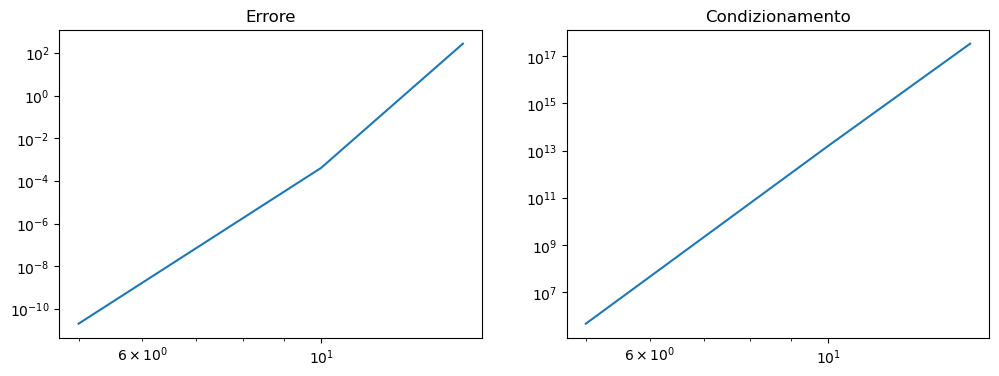

In [5]:
err = []
cond = []
N = np.array([5, 10, 15])
for n in N:
    A = scipy.linalg.hilbert(n)
    P, L, U = scipy.linalg.lu(A)
    x_ex = np.ones(n)
    b = A @ x_ex
    y = fwsub(L, P.T @ b)
    x = bksub(U, y)
    cond.append(np.linalg.cond(A))
    err.append(np.linalg.norm(x - x_ex) / np.linalg.norm(x_ex))

print(cond)
print(err)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.loglog(N, err)
plt.title("Errore")
plt.subplot(1, 2, 2)
plt.loglog(N, cond)
plt.title("Condizionamento")

Dal grafico ottenuto osserviamo che per matrici di dimensioni maggiori l'errore cresce molto, questo si spiega con l'aumento del numero di condizionamento della matrice, che raggiunge valori superiori a 10^17.

# **Esercizio 2 (10 punti)**


Si consideri il seguente integrale definito
\begin{gather*}
    I = \int_a^{b} f(x) dx
    \quad \text{per} \quad
    f(x) = x \sin( x)
\end{gather*}


#### **(2a) (1 punti) [P+T]** 
Calcolare il valore esatto dell'integrale con $a=0$ e $b=1$.

##### **Soluzione.** 

Definiamo la funzione, l'intervallo e l'integranda per poter calcolare il valore esatto dell'integrale.

In [6]:
from functions import pmedcomp, trapcomp
import numpy as np
import matplotlib.pyplot as plt

In [7]:
a = 0
b = 1
f = lambda x: x * np.sin(x)
F = lambda x: np.sin(x) - x * np.cos(x)
I = F(b) - F(a)
print(I)

0.30116867893975674


#### **(2b) (4 punti) [T]** 

Introdurre brevemente i metodi del punto medio e dei trapezi nella versione composita. Qual è l'ordine di accuratezza per tali metodi? E il loro grado di esattezza?

##### **Soluzione.**

La formula del punto medio, in cui approssimiamo $I$ utilizzando il valore della funzione nel punto medio dell'intervallo, è   data da
\begin{gather*}
    I \approx I_s = (b-a)  f\left( m \right),
\end{gather*}
dove $m = 0.5 (a+b)$, il cui errore è dato da
\begin{gather*}
    |E_{pm}|\leq \frac{(b-a)^3}{24}  \max_{x \in I} |f^{\prime\prime}(x)|
\end{gather*}

La formula dei trapezi è   data da
\begin{gather*}
     I \approx I_{t} = \frac{b-a}{2} \left[ f(a) + f(b) \right]
\end{gather*}
 il cui errore è dato da
\begin{gather*}
    |E_t| \leq \frac{(b-a)^3}{12} \max_{x\in[a,b]} |f^{\prime\prime}(x)|
\end{gather*}

Nell'integrazione composita suddividiamo l'intervallo $[a,b]$ in $n$ sotto-intervalli, dove, per $i=1,\ldots,n$, ogni intervallo \`e dato da $I_i = [x_{i-1}, x_i]$ con $x_i= a+ iH$ e dove $H=(b-a)/n$. Otteniamo così la formula del punto medio composito, 
\begin{gather*}
      I_{pm}^c = H \sum_{i=1}^n f\left(\frac{x_{i-1} + x_i}{2}\right).
\end{gather*}
e la formula dei trapezi composita,
\begin{gather*}
    I_t^c = \frac{H}{2} \sum_{i=1}^n \left[ f(x_{i-1}) + f(x_i) \right] =
    \frac{H}{2}[f(a) + f(b)] + H \sum_{i=1}^{n-1} f(x_i)
\end{gather*}

L'ordine di accuratezza è pari a 2, e il grado di esattezza è pari a 1 per entrambe le formule.

#### **(2c) (4 punti) [P]** 
Usando le funzioni *pmedcomp* e *trapcomp* (fornite in functions.py) calcolare un'approssimazione di $I$ suddividendo l'intervallo di integrazione  in $N = [10,20,40,80]$ sotto-intervalli.
Calcolare l'errore ottenuto nei due casi e rappresentarlo in scala logaritmica. Commentare i risultati ottenuti alla luce della teoria.

##### **Soluzione.**

Consideriamo il seguente condice.

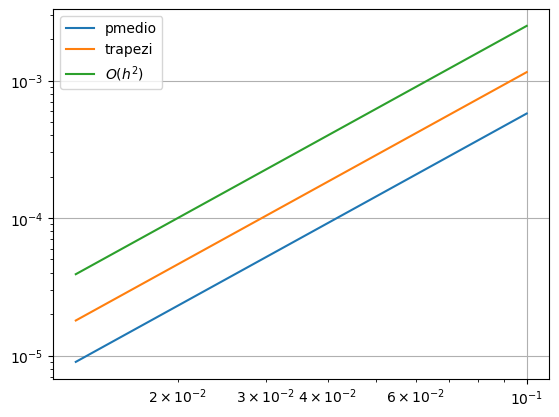

In [8]:
N = np.array([10, 20, 40, 80])

errPM = []
errT = []

for n in N:
    IPM = pmedcomp(f, a, b, n)
    errPM.append(np.abs(IPM - I))
    IT = trapcomp(f, a, b, n)
    errT.append(np.abs(IT - I))

plt.figure()
plt.loglog(1.0 / N, errPM, label="pmedio")
plt.loglog(1.0 / N, errT, label="trapezi")
plt.loglog(1.0 / N, 0.25 / (N**2), label="$O(h^2)$")
plt.grid()
plt.legend()

Possiamo osservare che, come previsto dalla teoria, l'errore decresce con ordine 2 in entrambi i casi, e i due metodi differiscono solo per la costante dell'errore.

#### **(2d) (1 punti) [T]** 

Utilizzando i dati a disposizione e la funzione $f$ fornita stimare la costante $C$ tale per cui $E_PM< CH^2$ per il metodo del punto medio.

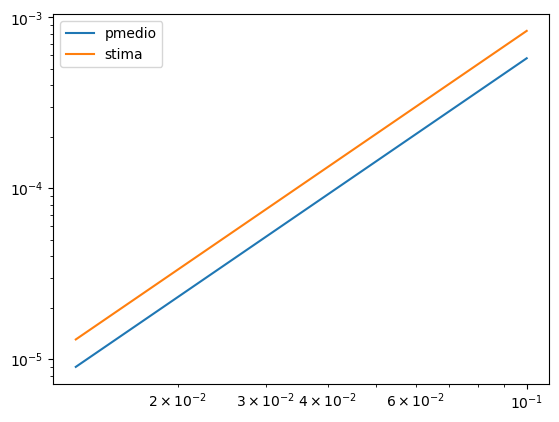

In [9]:
# f''(x) = 2 * cos(x) - x*sin(x) -> max f'' = 2
C = 2 / 24 * (1 - 0)

plt.figure()
plt.loglog(1.0 / N, errPM, label="pmedio")
plt.loglog(1.0 / N, C * 1 / (N**2), label="stima")
plt.legend()

# **Esercizio 3 (10 punti)**

Assumendo $c > 0$, si consideri la seguente equazione di conservazione

$$\begin{cases}
\partial_t c + \partial_x(4c) = 0\qquad x\in(0,5),\;t\in(0,T]\\
c(0,x) = \begin{cases}
1\qquad x<2 \\
0\qquad x>2 
\end{cases}\\
c(t,0) = 0\qquad t\in(0,T]
\end{cases}$$

dove il tempo finale è pari a $T = 1$.

#### **(3a) (3 punti) [T]** 

Illustrare il flusso numerico Upwind per la soluzione di leggi di conservazione con il metodo dei volumi finiti. Verificare se il flusso Upwind è applicabile per il problema in esame.

##### **Soluzione.** 

Se il flusso $f(c)$ è monotono, ossia $f^\prime(c)>0$ (o $f^\prime(c)<0$) per per ogni valore di $c\in[c_m, c_M]$ dove $c_m$ e $c_M$ sono il massimo e minimo valore della condizione iniziale $c^0$, allora possiamo usare il cosiddetto flusso upwind definito sull'interfaccia $i+\frac{1}{2}$ fra la cella $i$ e la cella $i+1$ come
\begin{gather*}
    F^{UP}_{i+\frac{1}{2}}(c_i, c_{i+1}) =
    \begin{cases}
        f(c_i)  &  \mathrm{se}\, f^\prime(c)\geq0\, \forall c\in[c_i, c_{i+1}]\\
        f(c_{i+1}) & \mathrm{se}\, f^\prime(c)\leq0\, \forall c\in[c_i, c_{i+1}]
    \end{cases}.
\end{gather*}    
Nel caso in esame abbiamo $f(c)=4c$ e $f'(c)=4$. In base ai dati iniziali forniti il valore minimo e massimo di $c$ sono rispettivamente $c_m=0$, $c_M=1$ e, per tali valori, la derivata prima della funzione flusso è sempre positiva quindi il flusso upwind è applicabile.

#### **(3b) (1 punti) [T]**  

Scegliere il valore $h=0.125$ costante per l'ampiezza delle celle. Calcolare quindi il massimo $\Delta t$ ammesso per il problema in esame e chiamare $\Delta t_{max}$ tale valore.

##### **Soluzione.**   

Per soddisfare la condizione CFL dobbiamo garantire che $\Delta t \max_{c\in(c_m,c_M)} |f'(c)|<h$. Con i valori scelti si ottiene $\Delta t_{max}=0.125/4=0.03125$.

#### **(3c) (3 punti) [P+T]**  

Sia $N = T / \Delta t_{max}$, risolvere il problema utilizzando la function *fvsolve* fornita in *utils_solver_cl.py* utilizzando il metodo Upwind per $N$, $N-2$ e $2N$ passi temporali (attenzione: calcolare i $\Delta t$ corrispondenti!) e rappresentare le soluzioni ottenute usando la function *xtplot* fornita in *utils_plot_cl.py*. Cosa si osserva?

##### **Soluzione.**

Consideriamo il seguente codice

0.03125


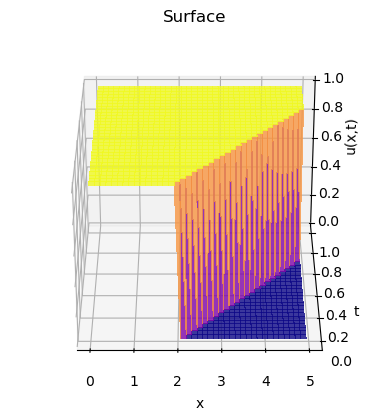

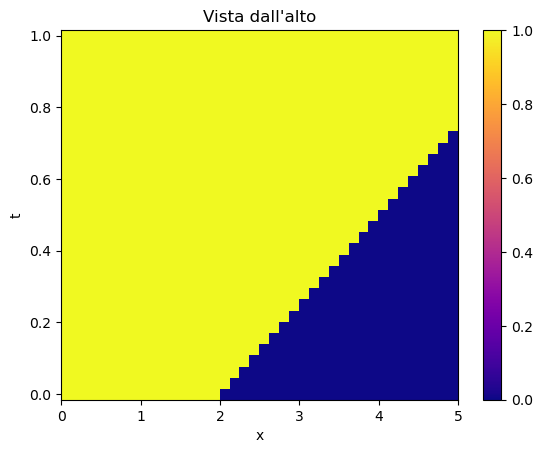

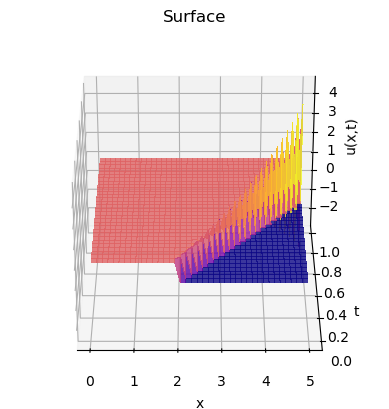

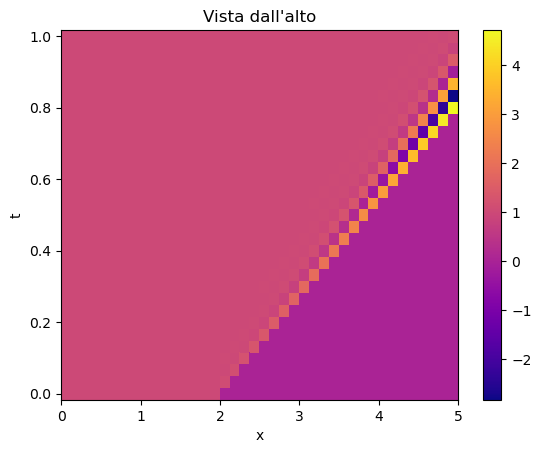

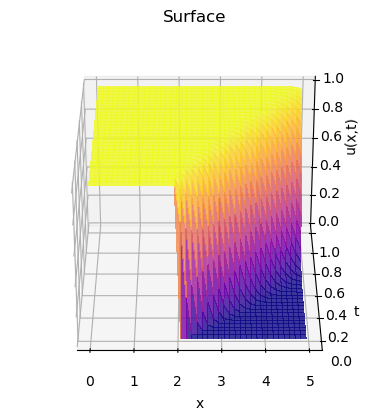

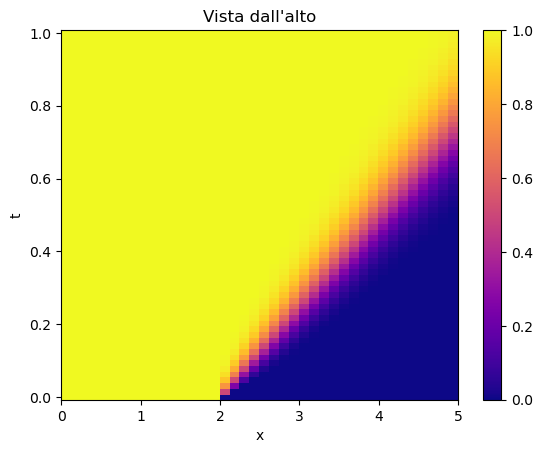

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import functions
from utilis_plot_cl import xtplot

# Dati del problema
u0 = lambda x: (x < 2)
f = lambda c: 4 * c
df = lambda c: 4

h = 0.125
dtlim = h / np.abs(df(1))
print(dtlim)
L = 5
T = 1
N = T / dtlim

# Soluzione per vari valori di N
for n in [N, N - 2, N * 2]:
    xc, t, u = functions.fvsolve(u0, f, df, L, T, h, T / n, "UPWIND")
    plt.figure()
    xtplot(xc, t, u, "surface")
    plt.show()

Osserviamo che per il passo  temporale ''limite'' la soluzione viene correttamente trasportata verso destra; per un passo temporale leggermente superiore al massimo consentito dalla CFL si osservano oscillazioni; per passi temporali minori si ha una soluzione corretta, con una maggiore diffusine numerica.

#### **(3d) (3 punti) [T]**

Calcolare la soluzione esatta del problema al tempo finale $t=T$ e confrontarla con i risultati ottenuti al punto precedente.

##### **Soluzione.** 

Si tratta di un problema di trasporto lineare, per cui la soluzione esatta è semplicemente
\begin{gather}
    c_e(t,x) = c_0(x-vt)
\end{gather}
dove $c_0$ è la condizione iniziale e, nel nostro caso, la velocità di trasporto è $v=4$. Al tempo $t=T=1$ quindi otteniamo 
\begin{gather}
    c_e(1,x) =
    \begin{cases}
        1 & x < 6 \\
        0 & x > 6
    \end{cases}
\end{gather}
Confrontando questa soluzione con le soluzioni numeriche si osserva che la velocità di trasporto è corretta, tuttavia la diffusione numerica può alterare il profilo della soluzione.